# 04 — Segmentation clients RFM

**Question métier :** quels clients portent le CA, et lesquels faut-il réactiver ?

**Méthode RFM :** chaque client acheteur est décrit par
- **Récence** : jours depuis le dernier achat (à la dernière date du dataset) ;
- **Fréquence** : nombre de commandes ;
- **Montant** : CA brut cumulé en USD.

La table de base `warehouse.Customer_RFM` est calculée en SQL (`sql/05_rfm.sql`) ; le scoring et la segmentation sont faits ici, puis réinjectés dans SQL Server pour Power BI.

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.db import get_engine, read_sql
from src.plotting import PALETTE, PRIMARY, percent, set_style

set_style()
engine = get_engine()

rfm = read_sql("SELECT * FROM warehouse.Customer_RFM", engine)
rfm[["Recency_Days", "Frequency", "Monetary_USD"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Recency_Days,1283707.0,217.780627,194.307223,0.000,80.00,140.000,345.00,807.000000
Frequency,1283707.0,3.378707,2.632995,1.000,1.00,3.000,4.00,35.000000
Monetary_USD,1283707.0,232.676487,223.167657,1.778,75.06,162.687,316.98,3252.878538


## 1. Distributions

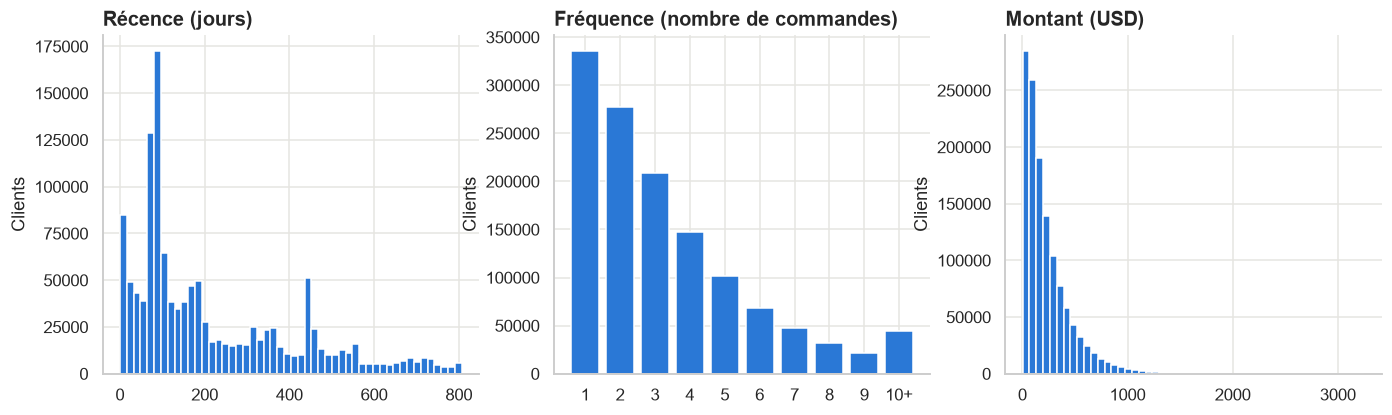

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(rfm["Recency_Days"], bins=50, color=PRIMARY)
axes[0].set_title("Récence (jours)")

frequency_counts = rfm["Frequency"].clip(upper=10).value_counts().sort_index()
axes[1].bar(frequency_counts.index, frequency_counts.values, color=PRIMARY)
axes[1].set_xticks(range(1, 11), [*map(str, range(1, 10)), "10+"])
axes[1].set_title("Fréquence (nombre de commandes)")

axes[2].hist(rfm["Monetary_USD"], bins=50, color=PRIMARY)
axes[2].set_title("Montant (USD)")

for ax in axes:
    ax.set_ylabel("Clients")
plt.show()

La **fréquence est très discrète** : 26 % des clients n'ont passé qu'une commande et la médiane est de 3. Un découpage en quintiles (`pd.qcut`) est donc inadapté : il faudrait départager arbitrairement des milliers de clients strictement identiques (deux clients avec 3 commandes pourraient recevoir des scores différents selon l'ordre des lignes). Le score F utilise donc des **seuils fixes et explicites**. Récence et montant, continus, restent découpés en quintiles.

## 2. Scoring (1 = moins bon, 5 = meilleur)

In [3]:
rfm["R_Score"] = pd.qcut(rfm["Recency_Days"], 5, labels=[5, 4, 3, 2, 1]).astype(int)  # récent = mieux
rfm["F_Score"] = pd.cut(rfm["Frequency"], bins=[0, 1, 2, 3, 5, np.inf], labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M_Score"] = pd.qcut(rfm["Monetary_USD"], 5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm["RFM_Score"] = rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str) + rfm["M_Score"].astype(str)

rfm.groupby("F_Score")["Frequency"].agg(["min", "max", "count"])

,min,max,count
F_Score,,,
1,1,1,335574
2,2,2,277798
3,3,3,208442
4,4,5,248731
5,6,35,213162


## 3. Segmentation

Segments définis sur la récence (le client est-il encore actif ?) et la fréquence (est-il fidèle ?) :

| Segment | Règle | Lecture |
|---|---|---|
| VIP | R ≥ 4 et F ≥ 4 | récents et très fidèles |
| Loyal | R ≥ 3 et F ≥ 3 | réguliers |
| New Customers | R ≥ 4 et F ≤ 2 | récents, peu d'historique |
| Potential Loyalist | R = 3 et F ≤ 2 | à convertir en clients réguliers |
| At Risk | R ≤ 2 et F ≥ 3 | anciens bons clients qui décrochent |
| Lost | R ≤ 2 et F ≤ 2 | inactifs et peu engagés |

In [4]:
r, f = rfm["R_Score"], rfm["F_Score"]
rfm["Segment"] = np.select(
    condlist=[
        (r >= 4) & (f >= 4),
        (r >= 3) & (f >= 3),
        (r >= 4) & (f <= 2),
        (r == 3) & (f <= 2),
        (r <= 2) & (f >= 3),
    ],
    choicelist=["VIP", "Loyal", "New Customers", "Potential Loyalist", "At Risk"],
    default="Lost",
)

segments = rfm.groupby("Segment").agg(
    Customers=("Customer_Key", "count"),
    Avg_Recency_Days=("Recency_Days", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary_USD=("Monetary_USD", "mean"),
    Revenue_USD=("Monetary_USD", "sum"),
)
segments["Share_Customers"] = segments["Customers"] / segments["Customers"].sum()
segments["Share_Revenue"] = segments["Revenue_USD"] / segments["Revenue_USD"].sum()
segments = segments.sort_values("Revenue_USD", ascending=False)

segments.style.format({
    "Customers": "{:,}", "Avg_Recency_Days": "{:.0f}", "Avg_Frequency": "{:.1f}",
    "Avg_Monetary_USD": "{:,.0f}", "Revenue_USD": "{:,.0f}",
    "Share_Customers": "{:.1%}", "Share_Revenue": "{:.1%}",
})

,Customers,Avg_Recency_Days,Avg_Frequency,Avg_Monetary_USD,Revenue_USD,Share_Customers,Share_Revenue
Segment,,,,,,,
VIP,"290,144",56,6.6,446,"129,434,543",22.6%,43.3%
Loyal,"239,351",111,4.1,292,"69,811,714",18.6%,23.4%
At Risk,"140,840",326,4.0,275,"38,712,143",11.0%,13.0%
Lost,"370,210",452,1.4,95,"35,079,642",28.8%,11.7%
New Customers,"138,048",63,1.6,97,"13,325,972",10.8%,4.5%
Potential Loyalist,"105,114",143,1.6,117,"12,324,422",8.2%,4.1%


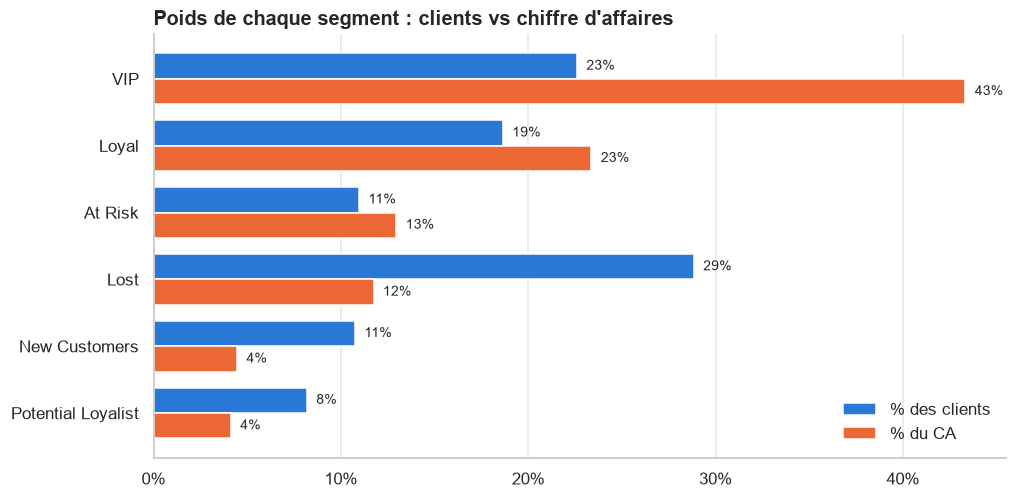

In [5]:
order = segments.index[::-1]
y = np.arange(len(order))
height = 0.38

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(y + height / 2, segments.loc[order, "Share_Customers"], height, color=PALETTE[0], label="% des clients")
ax.barh(y - height / 2, segments.loc[order, "Share_Revenue"], height, color=PALETTE[1], label="% du CA")
for offset, column in [(height / 2, "Share_Customers"), (-height / 2, "Share_Revenue")]:
    for yi, value in zip(y, segments.loc[order, column]):
        ax.text(value + 0.005, yi + offset, f"{value:.0%}", va="center", fontsize=9)

ax.set_yticks(y, order)
ax.xaxis.set_major_formatter(percent())
ax.set_title("Poids de chaque segment : clients vs chiffre d'affaires")
ax.legend(frameon=False, loc="lower right")
ax.grid(axis="y", visible=False)
plt.show()

**À retenir :**
- Le poids d'un segment en **nombre de clients ne reflète pas sa contribution au CA** : les **VIP (22,6 % des clients) génèrent 43,3 % du CA** — avec les Loyal, 41 % des clients font 67 % du CA. À l'inverse, **Lost est le segment le plus nombreux (28,8 %) pour 11,7 % du CA**.
- **At Risk** (141 000 clients, 13 % du CA) est la priorité : ce sont d'anciens clients réguliers (4 commandes en moyenne, 275 $ dépensés) sans achat depuis ~11 mois. Ils sont encore récupérables, contrairement aux Lost (1,4 commande en moyenne).

**Recommandations par segment :**

| Segment | Action |
|---|---|
| VIP | Programme de fidélité, avant-premières ; ne pas les sur-solliciter avec des remises |
| Loyal | Montée en gamme, ventes croisées entre catégories |
| New Customers | Parcours d'onboarding pour déclencher la 2e commande |
| Potential Loyalist | Relance personnalisée sur les catégories déjà achetées |
| At Risk | **Campagne de réactivation prioritaire** (offre ciblée, enquête de satisfaction) |
| Lost | Relances à faible coût uniquement ; ne pas y concentrer le budget |

## 4. Export vers SQL Server (Power BI)

In [6]:
columns = ["Customer_Key", "Recency_Days", "Frequency", "Monetary_USD",
           "R_Score", "F_Score", "M_Score", "RFM_Score", "Segment"]
rfm[columns].to_sql("Customer_Segments", engine, schema="warehouse",
                    if_exists="replace", index=False, chunksize=5_000)
print(f"{len(rfm):,} clients exportés vers warehouse.Customer_Segments")

1,283,707 clients exportés vers warehouse.Customer_Segments


## Limites

- **Photographie à une date** : la récence est mesurée au 18 mars 2025 ; les segments évoluent dans le temps et doivent être recalculés régulièrement.
- **Montant brut** : les retours ne sont pas déduits (choix classique, mais un client qui retourne beaucoup peut être surévalué).
- **Règles de segmentation** : les seuils sont standards mais arbitraires ; en entreprise, ils seraient validés avec les équipes marketing.
- **Ne pas croiser ces segments avec le label de churn historique** (notebook 05) : la récence actuelle contient déjà l'information « a acheté ou non ces 90 derniers jours ». Un taux de churn par segment serait mécaniquement proche de 100 % pour At Risk / Lost et de 0 % pour les VIP (raisonnement circulaire).